# Step Response Analysis (Problem L6.4)

This notebook compares measured and theoretical step responses using data from lab6.csv.

Step index: 128
10%-90% rise time: 9.00 ms
Estimated zeta: 0.610
Estimated wn: 200.0 rad/s


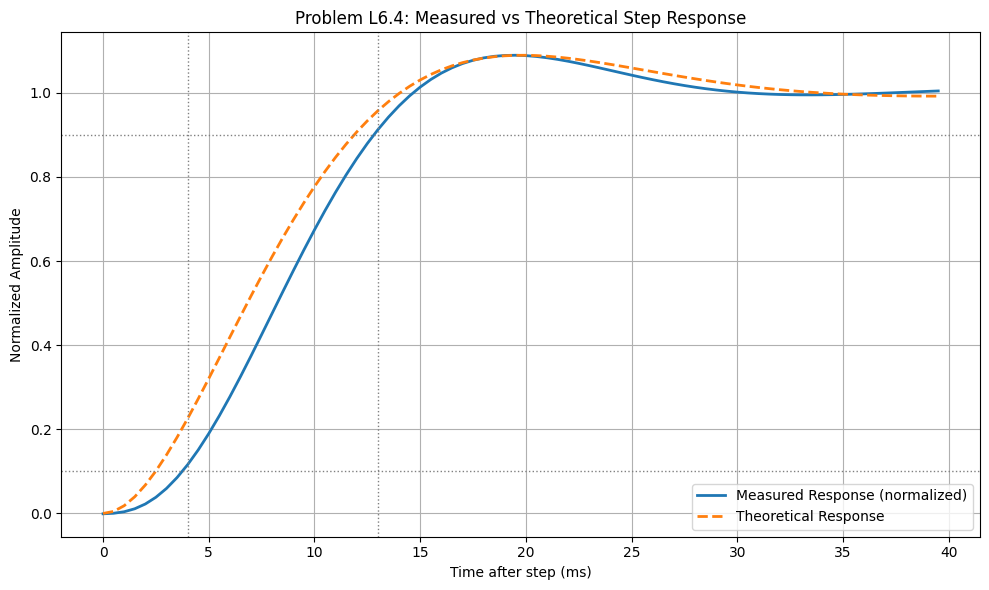

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --------------------------------------------------
# Load CSV data
# --------------------------------------------------
df = pd.read_csv("lab6.csv")

# Convert ms -> s for a physically meaningful time axis
t = df["t"].to_numpy() / 1000.0
x = df["x"].to_numpy()
y = df["y"].to_numpy()

# --------------------------------------------------
# Detect a major rising input edge
# --------------------------------------------------
dx = np.diff(x)
threshold = 0.5 * np.max(np.abs(dx))
edge_indices = np.where(np.abs(dx) >= threshold)[0]
rising_indices = np.where(dx >= threshold)[0]

if len(rising_indices) > 0:
    # Use the strongest rising edge (best match to 10%-90% rise-time measurement)
    step_index = rising_indices[np.argmax(dx[rising_indices])]
else:
    # Fallback: strongest edge regardless of direction
    step_index = edge_indices[np.argmax(np.abs(dx[edge_indices]))]

# Build a window around the step and avoid the next transition in the square wave
start = max(step_index - 20, 0)
default_end = min(step_index + 80, len(t) - 1)

next_edges = edge_indices[edge_indices > step_index + 5]
if len(next_edges) > 0:
    guard = max(10, int(0.8 * (next_edges[0] - step_index)))
    end = min(step_index + guard, default_end)
else:
    end = default_end

t_raw = t[start:end + 1]
y_raw = y[start:end + 1]

# Local index where the new step level starts
local_step_idx = (step_index + 1) - start

# --------------------------------------------------
# Normalize measured response to 0 -> 1
# --------------------------------------------------
pre_slice_start = max(local_step_idx - 10, 0)
y_initial = np.mean(y_raw[pre_slice_start:local_step_idx])
y_final = np.mean(y_raw[-10:])
y_measured = (y_raw - y_initial) / (y_final - y_initial)

# Use post-step data for direct comparison with a unit-step model
t_step = t_raw[local_step_idx:] - t_raw[local_step_idx]
y_step = y_measured[local_step_idx:]

# --------------------------------------------------
# Estimate 10%-90% rise time from measured data
# --------------------------------------------------
idx10 = np.where(y_step >= 0.1)[0][0]
idx90 = np.where(y_step >= 0.9)[0][0]
t10 = t_step[idx10]
t90 = t_step[idx90]
rise_time = t90 - t10

# Estimate damping from measured overshoot
overshoot = max(0.0, np.max(y_step) - 1.0)
if overshoot > 1e-6:
    ln_mp = np.log(overshoot)
    zeta = -ln_mp / np.sqrt(np.pi**2 + ln_mp**2)
else:
    zeta = 0.70

# Use rise-time approximation for a 2nd-order system
wn = 1.8 / max(rise_time, 1e-6)

num = [wn**2]
den = [1, 2 * zeta * wn, wn**2]
system = signal.TransferFunction(num, den)

tout, y_theory = signal.step(system, T=t_step)

print(f"Step index: {step_index}")
print(f"10%-90% rise time: {rise_time * 1000:.2f} ms")
print(f"Estimated zeta: {zeta:.3f}")
print(f"Estimated wn: {wn:.1f} rad/s")

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(t_step * 1000, y_step, linewidth=2, label="Measured Response (normalized)")
plt.plot(tout * 1000, y_theory, "--", linewidth=2, label="Theoretical Response")
plt.axhline(0.1, color="gray", linestyle=":", linewidth=1)
plt.axhline(0.9, color="gray", linestyle=":", linewidth=1)
plt.axvline(t10 * 1000, color="gray", linestyle=":", linewidth=1)
plt.axvline(t90 * 1000, color="gray", linestyle=":", linewidth=1)
plt.title("Problem L6.4: Measured vs Theoretical Step Response")
plt.xlabel("Time after step (ms)")
plt.ylabel("Normalized Amplitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()